In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn


# Dataloader


In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),                    # convert image to HxWxC tensors with floats in [0,1]
    transforms.Normalize((0.5,), (0.5,)),     # [-1, 1], cause we do (img - 0.5)/0.5 to get a centered around 0 and unit distribution
])

train_set = datasets.MNIST(
    root="./data",        
    train=True,
    download=True,
    transform=transform,
)

test_set = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

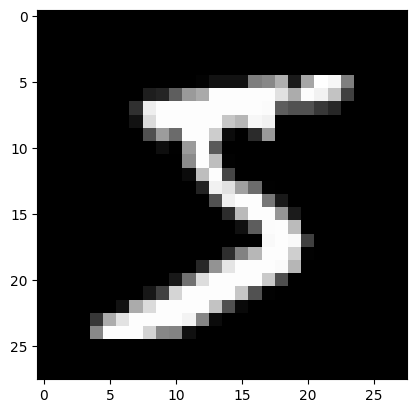

In [4]:
x0, y0 = train_set[0]   # x.shape = 1,28,28
plt.imshow(x0[0,:,:], cmap='grey')

In [ ]:
t = torch.tensor([500,0,3])
tp = torch.tensor([500,0,3]).long()
print(t.dtype, tp.dtype)

torch.int64 torch.int64


### LETS DO THE FORWARD PROCESS FIRST

In [ ]:
ts=300

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
print(device)

cuda


In [ ]:
import math
def cosine_beta(ts,s=0.008):
    """
    cosine beta schedule
    """
    steps = torch.arange(ts+1,dtype=torch.float32) #float32 (not 16) is important here for the beginning of the training
    f_t = torch.cos( (math.pi/2)*(steps/ts + s)/(1+s))**2
    print(f_t.dtype)
    alphas = f_t/f_t[0]
    return torch.clip(1 - alphas[1:]/alphas[:-1], 0 , 0.999)

In [9]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, timesteps=300, beta_start=3.3e-4, beta_end=0.07):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        # betas = torch.linspace(beta_start, beta_end, timesteps)
        betas = cosine_beta(timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.)

        self.register_buffer("betas",betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)
        self.register_buffer("sqrt_alphas_cumprod",  torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod",torch.sqrt(1. - alphas_cumprod))

    
    
    def q_sampling(self, x0, t, noise):
        """ 
        Computing q(x_t | x0) for batch=b
        Cautious with dimensions!:
        x0 : b x C x H x W
        noise : x0 like 
        t : b
        """
        sqrt_alpha_t           = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)           # (B, 1, 1, 1)
        sqrt_one_minus_alpha_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) # like ^

        x_t = sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise
        return x_t
    
    def p_loss(self, x0, context=True):
        """
        Compute the loss from x0 -> (B, *)
        """
        B, nts = x0.shape[0], self.timesteps # we need that for the time 
        t = torch.randint(nts, (B,), device=x0.device) #we take t uniform, but this isn't optimal since the solution is easy for low t or high t, but harder for middle t.
        noise = torch.randn_like(x0)
        x_t = self.q_sampling(x0, t, noise) 
        if context == True:
            noise_pred = self.model(x_t, t)       
        else: 
            noise_pred = self.model(x_t)
        loss_t = ((noise - noise_pred)**2).mean(dim=(1,2,3))
        loss = loss_t.mean()
        return loss, loss_t, t
    
    def p_sampling(self, x, t, eps):
        """
        Computing x_t-1 from eps_theta and x_t
        """
        alpha_t = self.alphas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        beta_t = self.betas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x) # that one is important (will be zero in DDIM)
        x_t_1 = 1/torch.sqrt(alpha_t) * (x - ((1 - alpha_t)/sqrt_one_minus_alpha_bar_t) * eps) + torch.sqrt(beta_t) * z
        return x_t_1
    
    def p_sampling_ddim(self, x, t, eps, s):
        """
        DDIM method of sampling
        """
        alpha_s = self.sqrt_alphas_cumprod[s].view(-1, 1, 1, 1) #being careful with broadcasting
        alpha_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_s = self.sqrt_one_minus_alphas_cumprod[s].view(-1, 1, 1, 1)
        # z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x) # that one is important (will be zero in DDIM)
        x_s = alpha_s/alpha_t * (x - sqrt_one_minus_alpha_bar_t * eps) + sqrt_one_minus_alpha_bar_s * eps
        return x_s
        

### DDIM

How is it possible that we can do a fewer steps than what we expected and have a deterministic sampling ? We thought till there that we had a Markov chain and to reverse it, we needed some noise. 

### Clarification

C'est intéréssant de voir qu'on va prédire le bruit ajouté pour passer de x0 à x_t tandis que dans la loss théorique initiale, on souhaite prédire les distributions postérieures: q(x_t-1 | x_t). Pour comprendre pourquoi, il n'y a pas de soucis, faut se rappeler que le modèle prédit non pas le bruit exacte eps | x_t, t, mais il prédit E(eps| x_t, t) ce qui revient à prédire E(x0 | x_t, t). Notre modèle fournit une estimation de E(x0 | x_T, T) certes, donc on pourrait passer de x_T à un approché de x0, mais celui-ci correspond à la moyenne des données comme x_T correspond quasi à du bruit... C'est pourquoi même si on prédit le bruit de x0 à xt, on fait du sampling step by step ou du moins pour l'instant.
Question: comment c'est possible de prendre 1 seul step si on sait que la trajectoire SDEs est une courbe?  

### Score connection?
The score isn't there in the equation, but the learned conditional noise corresponds to the score (adding a constant):  - (eps_theta (xt,t) )/sqrt(1 - alpha_bar_t) ~= grad log p(x_t) = E_x0( grad | x0) and gives us a geometric interpretetion. This follows from Tweedie's formula too.
This geometric interpretation looks the most useful: we go from x_T to x_0 by guiding it into the data distribution in space.
This gives us the idea of guidance too: we could guide the model to go to certain areas of the data distribution.


In [10]:
# g = GaussianDiffusion(model = None)
# noise = torch.randn_like(x0)
# t = torch.tensor([200]) 
# x_t = g.q_sampling(x0,t, noise)
# plt.imshow(x_t[0].squeeze(), cmap="gray")


### Let's do a small MLP first to then test our diffusion model before doing a U-NET

In [11]:
torch.tensor([1])/np.sqrt(2)

tensor([0.7071])

In [12]:
class neuro(nn.Module):
    def __init__(self, dim=28*28, t_dim=128, hidden_dim=512):
        super().__init__()
        self.t_net = nn.Sequential(
            nn.Linear(1, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),nn.SiLU(),
        )

        self.mlp = nn.Sequential(
            nn.Linear(dim + t_dim, hidden_dim//2), nn.SiLU(), # we concat enbedded time and and the vector
            nn.Linear(hidden_dim//2, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim), # we get back to our image
        )
    
    def forward(self, x, t):
        """
        x -> (B, C, H, W)
        t -> (B,)
        """
        B, C, H, W = x.shape
        t_emb = self.t_net(((t).float()).unsqueeze(-1)) #unsqueeze cause we're having (B,) for t and we want (B,1) (broadcast)
        x = torch.flatten(x, 1, -1)
        x_concat = torch.cat((x, t_emb), -1)
        out = self.mlp(x_concat)
        return out.view(B,C,H,W)
    


In [13]:
import math
class Sinusembed(nn.Module):
    """
    sinusoidal embedding of time
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        t -> (B,)
        """
        #device = x.device # maybe if I want to train on gpu with bigger models than mnist
        N=10000 #Attention is all you need  N**(k/(dim//2)) 
        h_dim = self.dim//2
        emb = math.log(N)/(h_dim)
        emb = torch.exp(torch.arange(h_dim) * -emb).to(device) # (h_dim,)  # I have to know when to put device or not
        emb = t[:, None] * emb[None,:] #careful with broadcast
        return torch.cat((emb.sin(), emb.cos()), dim=-1)




In [14]:
# #test Sinusembed
# t = torch.tensor([10,500,300]).to(device)
# embed = Sinusembed(16)
# t_emb = embed(t)
# t_emb.shape

In [15]:
class RMSnorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim**0.5
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
    def forward(self,x):
        return F.normalize(x, dim=1) * self.g * self.scale #Pytorch formula normalize is the L2 and then we have the



class Resblock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # self.norm1 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm1 = RMSnorm(out_ch) #we use RMSnorm which is more efficient
        self.act1 = nn.SiLU()
        
        self.time_proj = nn.Sequential(nn.SiLU(),nn.Linear(time_dim, 2 * out_ch)) # we're doing that for the scale and shift instead of just adding the time
        # self.time_proj = nn.Linear(time_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # self.norm2 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm2 = RMSnorm(out_ch)
        self.act2 = nn.SiLU()
        #res_conv = conv1x1 will be useful in upsampling
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity() #we need output and skip(x) to have the same dim
        # self.dropout = nn.Dropout(0.1) # let's see what it does
    def forward(self, x, t_emb=None):
        #block 1
        if t_emb is not None:
            t_context = self.time_proj(t_emb) #(B, 2 * out_ch)
            t_context = t_context[:,:,None,None] # We need the time_context to match output (B, 2 * out_ch, 1, 1)
            scale, shift = t_context.chunk(2, dim=1) #tuple (B, out_ch,1,1)
        
        h1 = self.conv1(x)
        h1 = self.norm1(h1)
        if t_emb is not None:
            h1 = h1 * (1 + scale) + shift #scale shift DONT FORGET TO TRY WHITHOUT SCALE adaGN
        h1 = self.act1(h1)
        #block 2
        # h1 = self.dropout(h1)
        h2 = self.conv2(h1)
        h2 = self.norm2(h2)
        h2 = self.act2(h2)
        return (h2 + self.res_conv(x)) /np.sqrt(2) #adding variance normalisation with 1/sqrt(2)  



In [16]:
# #test for the block (at least shape...)
# block = Resblock(in_ch=64, out_ch=128, time_dim=256)
# x = torch.randn(4, 64, 14, 14)
# t_emb = torch.randn(4, 256)
# out = block(x, t_emb)
# print(out.shape)

In [17]:
# dim = 5
# dim_mults = (1,2,4)
# dims = [dim] + [dim * m for m in dim_mults]
# in_out = list(zip(dims[:-1], dims[1:]))
# in_out_ups = [(b, a) for a, b in reversed(in_out)]
# print(in_out, in_out_ups)

In [18]:
def Downsample(dima, dimb):
    return nn.Conv2d(dima, dimb, kernel_size=2, stride=2) # we divide by 2 the image feature resolution
def Upsample(dima, dimb):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="bilinear"), #got helped by google on that one
        nn.Conv2d(dima, dimb, 3, padding=1),
    )
    

class Unet(nn.Module):
    def __init__(self,
                dim,# start dim of embedding in the Unet
                dim_mults=(2, 4),  # lets see
                channel=1  # input channel of our images, mnist is 1
    ):
        super().__init__()
        self.dim = dim
        self.channel = channel
        self.init_conv = nn.Conv2d(channel, dim, kernel_size=3, padding=1) #we keep the same image_size kernel=3 padd=1
        
        #getting the dimensions for ups and downs
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        
        #timesteps encoder
        time_dim = dim*4 # we make the time embeddign big enough to be approx equal to feature embedding
        self.t_embed = nn.Sequential(Sinusembed(self.dim), nn.Linear(dim, time_dim), nn.GELU(), nn.Linear(time_dim, time_dim))
        #ResBlocks downs
        self.downs = nn.ModuleList([])
        for (in_ch, out_ch) in in_out:
            down = nn.ModuleList([Resblock(in_ch, in_ch, time_dim), Resblock(in_ch, in_ch, time_dim), Downsample(in_ch, out_ch)])
            self.downs.append(down)
        
        #Midblocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim, time_dim)
        self.mid_block2 = Resblock(mid_dim, mid_dim, time_dim)

        # Resblock up
        self.ups = nn.ModuleList([])
        for (out_ch, in_ch) in reversed(in_out): #careful with the order in_ch, out_ch
            #we multiply by 2, cause we add the vector of the downresblocks as context
            up = nn.ModuleList([Upsample(in_ch, out_ch ),Resblock(2 * out_ch, out_ch, time_dim), Resblock(2 * out_ch, out_ch, time_dim)]) 
            self.ups.append(up)
        
        self.final_conv = nn.Conv2d(dim, channel, 1) #back to channel of the input

    def forward(self, x, t=None):
        if t is not None:
            t_emb = self.t_embed(t)
        else:
            t_emb=None
        x = self.init_conv(x)
        
        skips = []
        for down in self.downs:
            res1, res2, dsample = down
            x = res1(x, t_emb)
            skips.append(x)
            x = res2(x, t_emb)
            skips.append(x)
            x = dsample(x)
        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)
        for up in self.ups:
            upsample, res1, res2 = up
            x = upsample(x)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res1(x, t_emb)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res2(x, t_emb)
        x = self.final_conv(x)
        return x


        


In [19]:
# #test Unet
# x = torch.randn(4, 1, 28, 28, device=device) #SIZE OF RESOLUTION MUST MATCH THE SIZE IN DIM MULTS
# t = torch.tensor([10,500,300,50]).to(device)
# unet = Unet(16, (1,2), 1).to(device) #1 = channel of input x 
# out = unet(x, t)
# print(out.shape, x.shape)

In [20]:
# #test mlp
# x = torch.randn((4,1,28,28))
# t = torch.randint(0, ts-1, (4,))
# net = neuro()
# out = net(x,t)
# out.shape

torch.float32


/tmp/ipython-input-47-1961071261.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit


epoch 0: loss = 0.242473
epoch 100: loss = 0.050636
epoch 200: loss = 0.046783
epoch 300: loss = 0.041321
epoch 400: loss = 0.037907
epoch 500: loss = 0.026641
epoch 600: loss = 0.033807


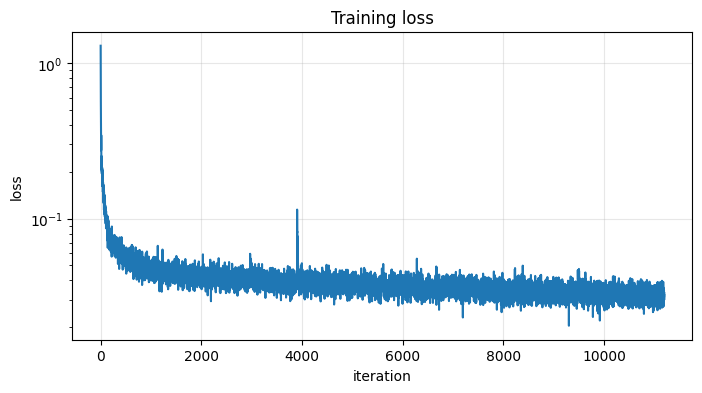

In [ ]:

model = torch.compile(Unet(64, (1,2), 1)).to(device) #before after? speeding

from torch.utils.data import Subset, DataLoader
# try +2000 to start getting results with DDIM
tiny_set = Subset(train_set, range(2000)) #using the whole dataset is too long to train
tiny_loader = DataLoader(tiny_set, batch_size=128, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
diff = GaussianDiffusion(model, timesteps=ts).to(device)
losses = []  
losses_t = [[] for _ in range(300)] #let's see the loss by timestep?
def train_loops(dataloader, diffusion, optimizer):
    diffusion.train()
    scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit
    for _, (X, _) in enumerate(dataloader):
        X = X.to(device)
        with torch.autocast("cuda"):
            loss, loss_t, t = diffusion.p_loss(X, context=True)
            t_np = t.detach().squeeze().cpu().numpy()
            loss_np = loss_t.detach().cpu().numpy()
            for i, l in zip(t_np, loss_np):
                losses_t[i].append(l)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        losses.append(loss.item())


epochs = 700 
for epoch in range(epochs):
    train_loops(tiny_loader, diff, optimizer)
    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {losses[-1]:.6f}")
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")  
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()



The sqrt(2) in the Unet might decrease the loss, but increases the robustess and we get better sampling

 Groupnorm is less efficient than RMSnorm (take less time to train), but gives a bit better results since it takes into account the spatial architecture of the features

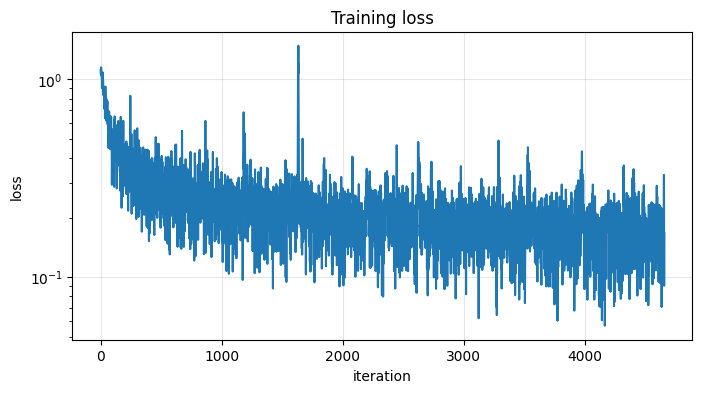

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(losses_t[0])
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")  
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

By watching the loss during the time, we see that loss will be higher for the smaller t (small steps). That's because at small steps, we didn't add that much noise and since we're predicting noise, the loss becomes something like a variance of a noise (not clear at the end) 

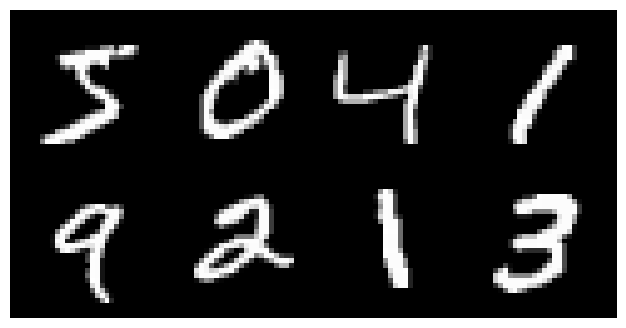

In [49]:
import torchvision.utils as vutils

imgs = torch.stack([tiny_set[i][0] for i in range(8)])
imgs = (imgs + 1) / 2
grid = vutils.make_grid(imgs, nrow=4)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.show()

### DDPM sampling

t=299 | x avant modele:  mean=+0.011 std=0.989
t=299 | x avant modele:  mean=-0.077 std=1.042
t=298 | x avant modele:  mean=-0.077 std=1.042
t=298 | x avant modele:  mean=-0.053 std=1.005
t=297 | x avant modele:  mean=-0.053 std=1.005
t=297 | x avant modele:  mean=-0.033 std=1.003
t=296 | x avant modele:  mean=-0.033 std=1.003
t=296 | x avant modele:  mean=-0.036 std=0.994
t=295 | x avant modele:  mean=-0.036 std=0.994
t=295 | x avant modele:  mean=-0.030 std=0.996
t=294 | x avant modele:  mean=-0.030 std=0.996
t=294 | x avant modele:  mean=-0.032 std=1.003
t=293 | x avant modele:  mean=-0.032 std=1.003
t=293 | x avant modele:  mean=-0.038 std=0.998
t=292 | x avant modele:  mean=-0.038 std=0.998
t=292 | x avant modele:  mean=-0.038 std=0.997
t=291 | x avant modele:  mean=-0.038 std=0.997
t=291 | x avant modele:  mean=-0.041 std=0.989
t=290 | x avant modele:  mean=-0.041 std=0.989
t=290 | x avant modele:  mean=-0.049 std=0.987
t=289 | x avant modele:  mean=-0.049 std=0.987
t=289 | x ava

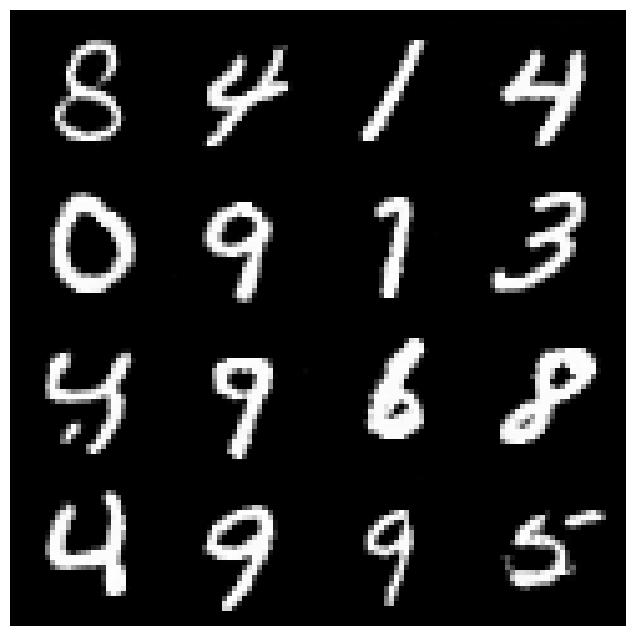

In [ ]:
import torchvision.utils as vutils

n_samples = 16

x_f = torch.randn(n_samples, 1, 28, 28, device=device)
model.eval()
with torch.no_grad():
    for t in range( 299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device) 
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling(x_f, t_batch, eps)
samples = ((x_f + 1) / 2).clamp(0, 1)
grid = vutils.make_grid(samples.detach().cpu(), nrow=4) #made by claude
plt.figure(figsize=(8, 8))                              #made by claude
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')  # that too
plt.axis('off')
plt.show()

### DDIM sampling

[299, 297, 295, 293, 291, 289, 287, 285, 283, 281, 279, 277, 275, 273, 271, 269, 267, 265, 263, 261, 259, 257, 255, 253, 251, 249, 247, 245, 243, 241, 239, 237, 235, 233, 231, 229, 227, 225, 223, 221, 219, 217, 215, 213, 211, 209, 207, 205, 203, 201, 199, 197, 195, 193, 191, 189, 187, 185, 183, 181, 179, 177, 175, 173, 171, 169, 167, 165, 163, 161, 159, 157, 155, 153, 151, 149, 147, 145, 143, 141, 139, 137, 135, 133, 131, 129, 127, 125, 123, 121, 119, 117, 115, 113, 111, 109, 107, 105, 103, 101, 99, 97, 95, 93, 91, 89, 87, 85, 83, 81, 79, 77, 75, 73, 71, 69, 67, 65, 63, 61, 59, 57, 55, 53, 51, 49, 47, 45, 43, 41, 39, 37, 35, 33, 31, 29, 27, 25, 23, 21, 19, 17, 15, 13, 11, 9, 7, 5, 3, 1, 0]
t=299 | x avant modele:  mean=+0.009 std=0.996
s=297 | x après modele:  mean=-0.144 std=0.567
t=297 | x avant modele:  mean=-0.144 std=0.567
s=295 | x après modele:  mean=-0.148 std=0.565
t=295 | x avant modele:  mean=-0.148 std=0.565
s=293 | x après modele:  mean=-0.154 std=0.564
t=293 | x avant mod

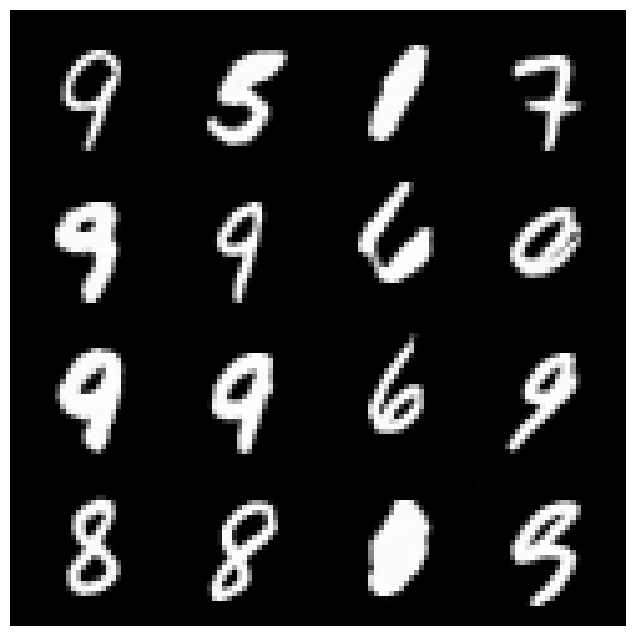

In [ ]:
import torchvision.utils as vutils
n_samples = 16
x_f = torch.randn(n_samples, 1, 28, 28, device=device)
model.eval()

timesteps = list(range(299, -1, -2))
timesteps.append(0)
print(timesteps)
with torch.no_grad():
    for i in range(len(timesteps) - 1):
        t, s = timesteps[i], timesteps[i + 1]
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)
        s_batch = torch.full((n_samples,), s, dtype=torch.long).to(device)
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling_ddim(x_f, t_batch, eps, s_batch)

samples = ((x_f + 1) / 2).clamp(0, 1)
grid = vutils.make_grid(samples.detach().cpu(), nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.axis('off')
plt.show()


### Interesting thing on DDIM

If you train the model on few data like I did, the DDIM won't work well even if the DDPM sampling work perfectly. 
We can understand that by taking the SDEs view of the reverse process. With DDIM, we take off the noise and have then a deterministic process. Remember that with the DDPM view, the reverse process was a markov chain, so actually the noise we added (and then removed in DDIM) comes form the Gaussian distribution that we're modelling for the reverse process using the "nice property".
This noise serves a regularizer, if our score isn't the perfect score, then the random noise compensate the accumulation of error a bit, but if we put that regularizer off, the error will accumulate within the reverse process and thus give bad results. 
I'm training only on a tiny subset of MNIST and thus the score isn't perfect or at least not enough to make the DDIM work., by adding more data and upgrading our model, we get better results on DDIM and can reduce by nice factors the number of steps (for 2k images as train_dataset, I can reduce it by a x5)


### Time as input?????

If you try to run the model without the time as input of the model, the result is interesting to interpret. Remember that we try to estimate E(eps | x_t, t), but if we ignore t, we just predict E(eps | x) where we have no more dependency of the time (our estimator become biaised). We see ,however, that sometimes we might have numbers like image, it's mostly luck since the variety of MNIST is small and even a biased estimator attracts toward digits. Nethertheless, it's not the only reason: without time, our estimator is E(eps |x_"t") or E(eps | y) = E_{t know y}[ E( eps |x_t, t)] and if we have a big mass on p(t | x_t), then we might have a good result since the without time estimator will be near from the "with time" estimator. With bigger model, maybe that the model without time could have better results by learning in which regime the input is (the image is noisy then we're near from t=T and if it's data-like, t =0), but it's inefficient.

In [53]:

from matplotlib import animation
from IPython.display import HTML
#this cell is made by AI
n_samples = 1
save_every = 5  
frames = []

x_f = torch.randn(n_samples, 1, 28, 28, device=device)

model.eval()
with torch.no_grad():
    for t in range(299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long, device=device)
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling(x_f, t_batch, eps)

        if t % save_every == 0:
            grid = vutils.make_grid(
                ((x_f + 1) / 2).clamp(0, 1).detach().cpu(), nrow=4
            )
            frames.append(grid.permute(1, 2, 0).numpy())

# Animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')
im = ax.imshow(frames[0], cmap='gray', animated=True)
title = ax.set_title('')

def update(i):
    im.set_data(frames[i])
    step = 299 - i * save_every
    title.set_text(f't = {step}')
    return im, title

anim = animation.FuncAnimation(
    fig, update, frames=len(frames), interval=100, blit=True
)
plt.close()
HTML(anim.to_jshtml())